**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 8**
Regresión Lineal

---

*   NOMBRE: Ricardo Martin Galvan Paez
*   MATRÍCULA: A01253169

En esta actividad trabajarás con el archivo `diamonds_dataset.csv`, basado en un conjunto de datos sobre características de diamantes, disponible en el paquete ggplot2 de R y en repositorios públicos de análisis de datos.

Los datos fueron recopilados para analizar el precio de los diamantes en función de sus propiedades físicas y cualidades de corte, color y claridad. Los indicadores incluidos son:

* `carat`: Peso del diamante en quilates
* `cut`: Calidad del corte del diamante (Fair, Good, Very Good, Premium, Ideal)
* `color`: Color del diamante, de D (mejor) a J (peor)
* `clarity`: Claridad del diamante (I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF)
* `depth`: Profundidad total del diamante como porcentaje: z / mean(x, y)
* `table`: Ancho de la tabla del diamante como porcentaje de x
* `x`: Longitud en mm
* `y`: Ancho en mm
* `z`: Profundidad en mm
* `price`: Precio del diamante en dólares estadounidenses. Es la variable de salida o *target*

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [ ]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Descarga el archivo: `diamonds_dataset.csv` y guarda, en un dataframe (`diamonds_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Verifica si alguna columna contiene valores faltantes.
* Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.



---
Existen 7 columnas numericas y 3 de texto


In [ ]:
diamonds_df = pd.read_csv('/content/drive/MyDrive/Posgrado/1er trimestre/TC5053.10_Ciencia y analítica de datos/Colab/Actividad 8 | Regresión lineal/diamonds_dataset.csv')
diamonds_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53916 entries, 0 to 53915
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53916 non-null  float64
 1   cut      53916 non-null  object 
 2   color    53916 non-null  object 
 3   clarity  53916 non-null  object 
 4   depth    53916 non-null  float64
 5   table    53916 non-null  float64
 6   x        53916 non-null  float64
 7   y        53916 non-null  float64
 8   z        53916 non-null  float64
 9   price    53916 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [ ]:
diamonds_df.nunique()

,0
carat,271
cut,5
color,7
clarity,8
depth,184
table,127
x,550
y,549
z,371
price,11595


In [ ]:
diamonds_df.isna().mean()*100

,0
carat,0.0
cut,0.0
color,0.0
clarity,0.0
depth,0.0
table,0.0
x,0.0
y,0.0
z,0.0
price,0.0


In [ ]:
diamonds_df.duplicated().sum()

np.int64(145)

In [ ]:
diamonds_df.drop_duplicates(inplace=True)
diamonds_df.reset_index(drop=True, inplace=True)
diamonds_df.duplicated().sum()

np.int64(0)

2. Obtén las estadísticas descriptivas, separando las variables numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Para las variables numéricas genera histogramas y boxplots para explorar la distribución y la dispersión.
* Para las variables categóricas utiliza diagramas de barras para visualizar la frecuencia de cada categoría.

In [ ]:
cat_cols = diamonds_df.select_dtypes(include='object')
num_cols = diamonds_df.select_dtypes(include='number')

In [ ]:
describe_df = diamonds_df[num_cols.columns].describe().T
describe_df['skew'] = diamonds_df[num_cols.columns].skew()
describe_df['kurtosis'] = diamonds_df[num_cols.columns].kurtosis()
describe_df

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
carat,53771.0,0.797323,0.472474,0.20,0.40,0.70,1.04,4.50,1.097608,1.103102
depth,53771.0,61.748160,1.429519,43.00,61.00,61.80,62.50,79.00,-0.113828,5.421229
table,53771.0,57.457635,2.233192,43.00,56.00,57.00,59.00,95.00,0.792130,2.775635
x,53771.0,5.731280,1.118102,3.73,4.71,5.70,6.54,10.23,0.394540,-0.714188
y,53771.0,5.734618,1.138982,3.68,4.72,5.71,6.54,58.90,2.470959,92.450005
z,53771.0,3.539774,0.701677,1.07,2.91,3.53,4.03,31.80,1.588322,48.121935
price,53771.0,3930.320545,3984.687429,326.00,951.00,2401.00,5323.50,18823.00,1.618372,2.180778


In [ ]:
cat_cols.describe().T

,count,unique,top,freq
cut,53771,5,Ideal,21485
color,53771,7,G,11254
clarity,53771,8,SI1,13030


In [ ]:
for col in cat_cols:
    print(f"Tabla de frecuencia para la columna '{col}':")
    print(diamonds_df[col].value_counts())
    print('-'*50)

Tabla de frecuencia para la columna 'cut':
cut
Ideal        21485
Premium      13737
Very Good    12065
Good          4888
Fair          1596
Name: count, dtype: int64
--------------------------------------------------
Tabla de frecuencia para la columna 'color':
color
G    11254
E     9776
F     9517
H     8266
D     6753
I     5404
J     2801
Name: count, dtype: int64
--------------------------------------------------
Tabla de frecuencia para la columna 'clarity':
clarity
SI1     13030
VS2     12225
SI2      9140
VS1      8155
VVS2     5056
VVS1     3646
IF       1784
I1        735
Name: count, dtype: int64
--------------------------------------------------


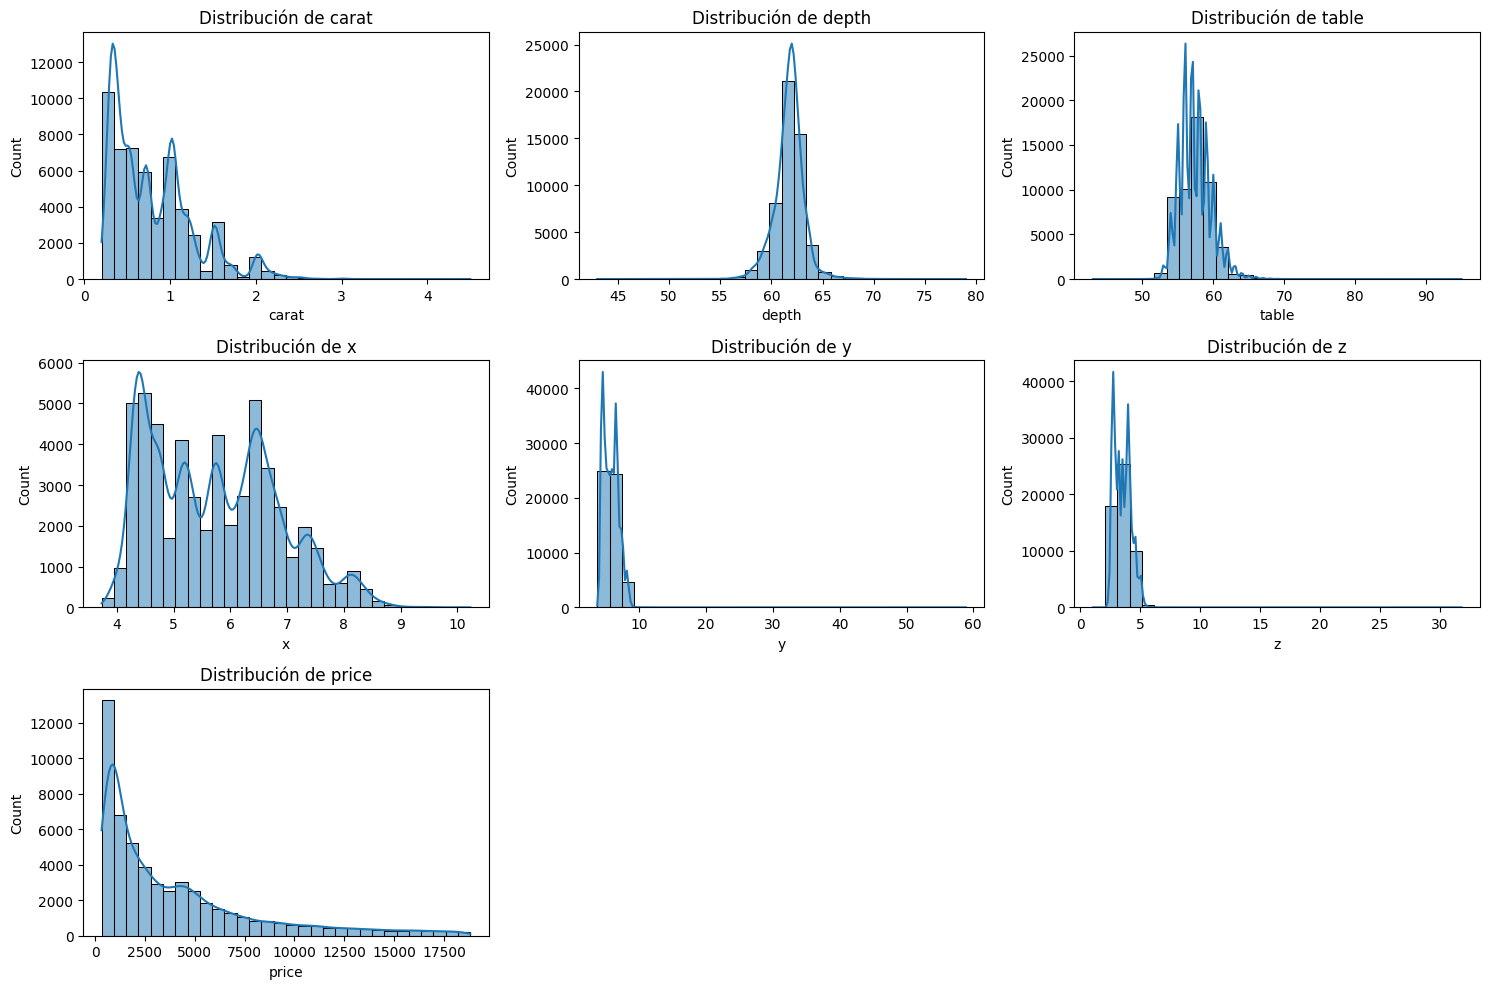

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols.columns):
    sns.histplot(data=diamonds_df, x=col, bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')

# Ocultar ejes vacíos si num_cols.columns < 9
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

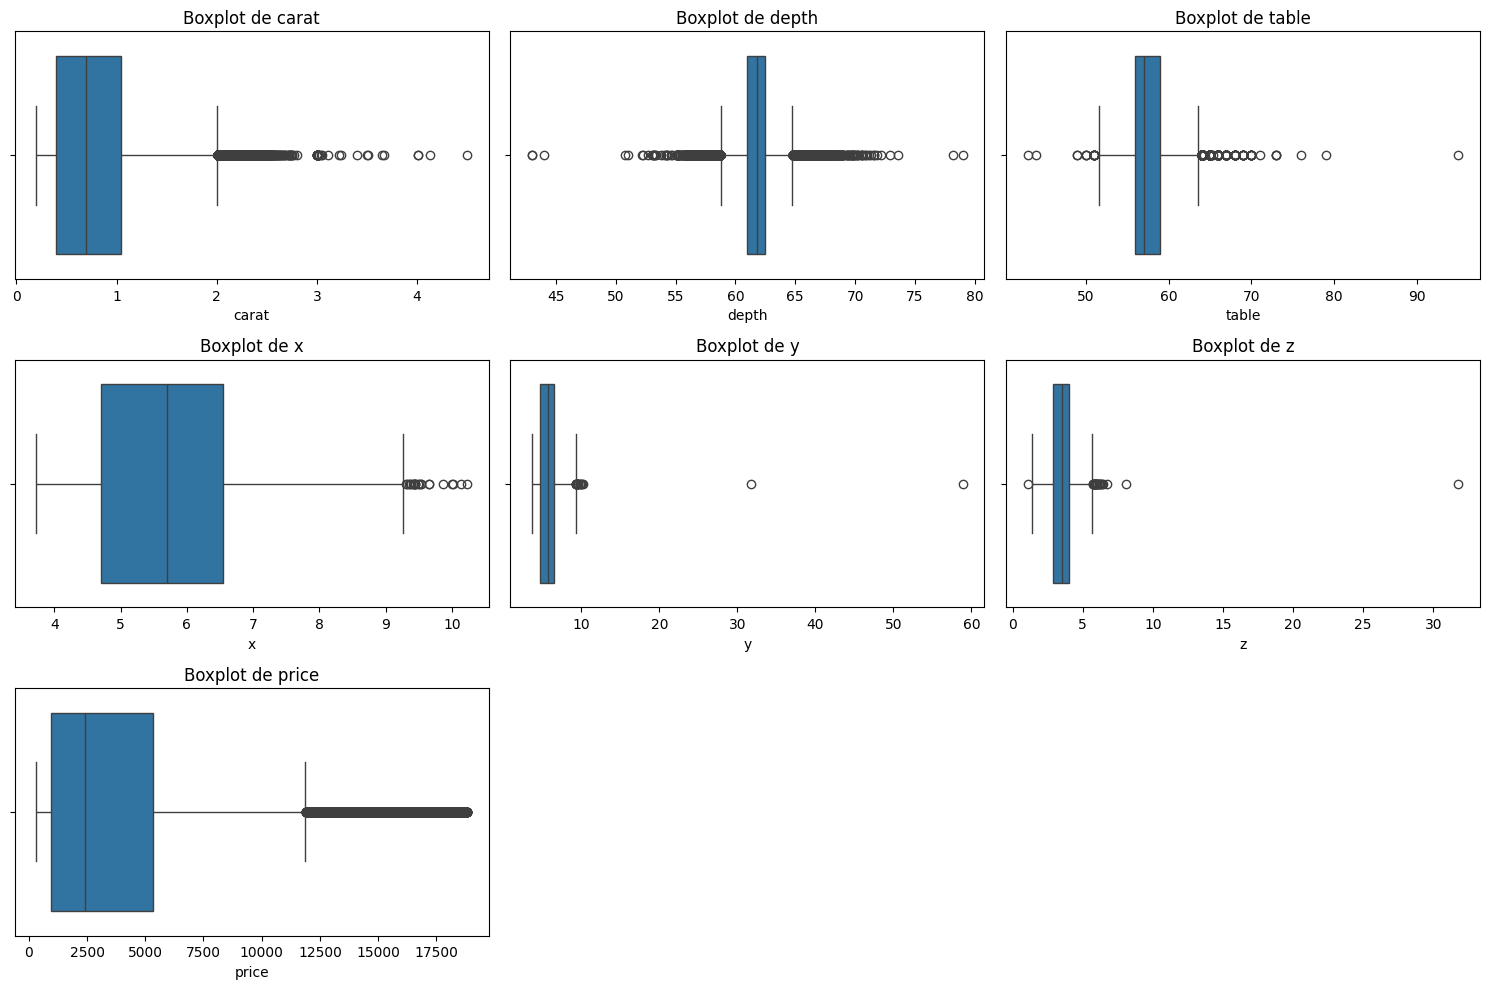

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols.columns):
    sns.boxplot(data=diamonds_df, x=col, ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

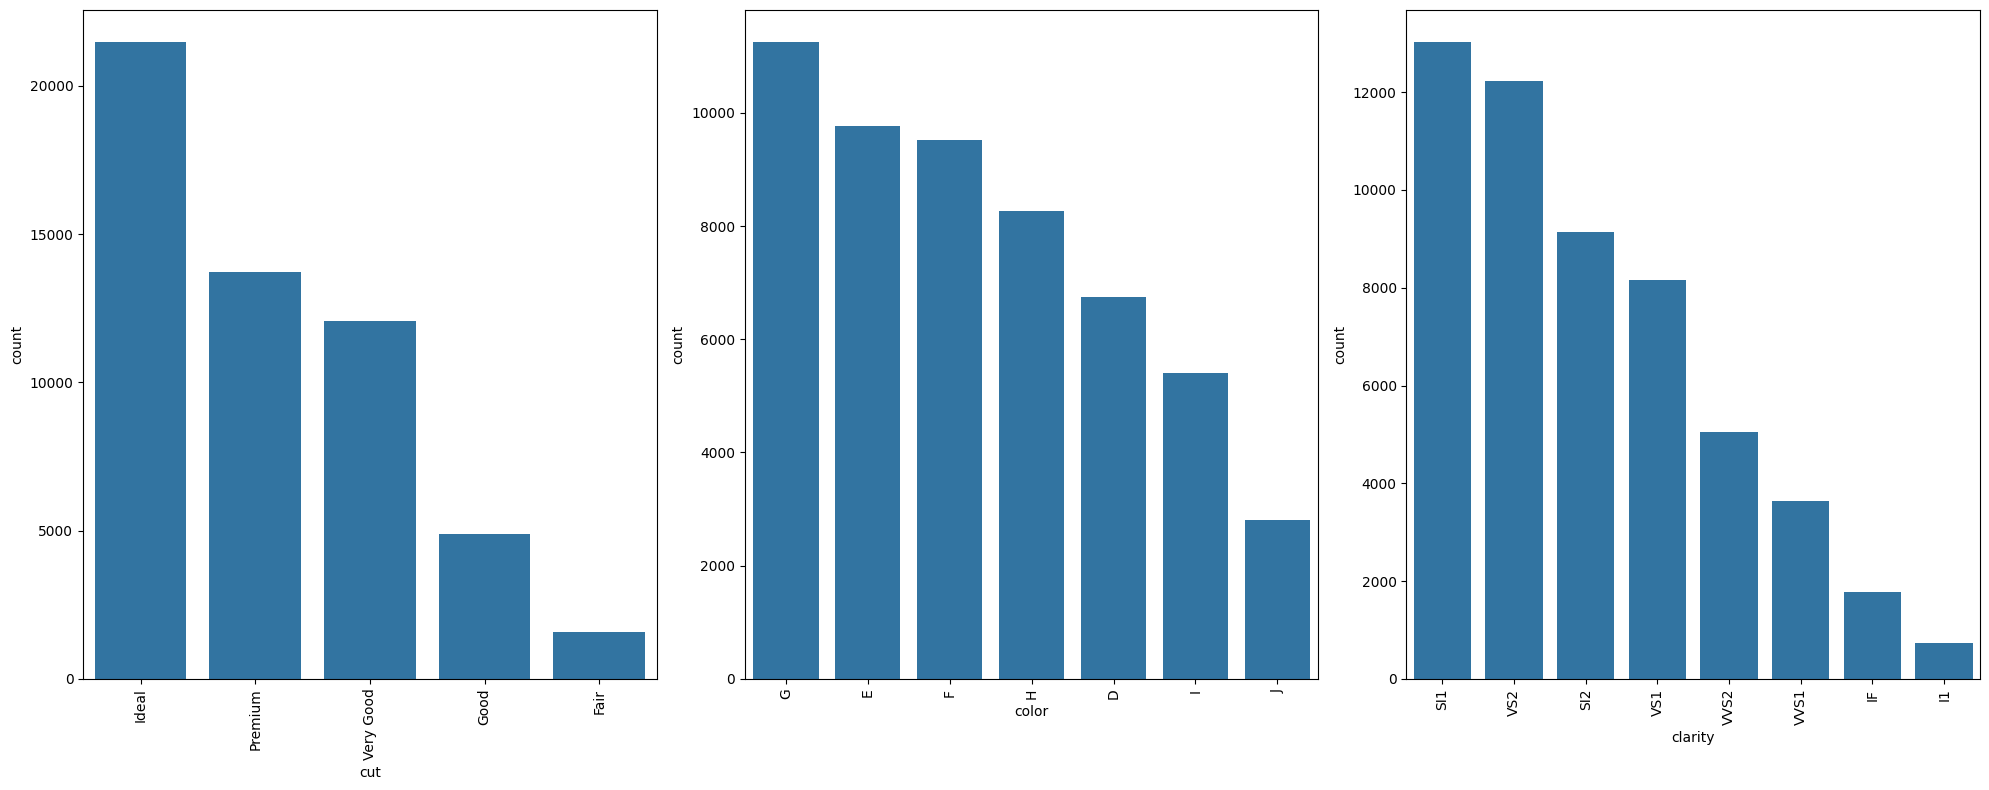

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(20,8))
axes = axes.ravel()
for col, ax in zip(diamonds_df[cat_cols.columns], axes):
  sns.countplot(x=diamonds_df[col], ax=ax, order=diamonds_df[col].value_counts().index[:10])
  ax.tick_params(axis='x',rotation=90)
  plt.tight_layout()


3. Explora relaciones bivariadas en el conjunto de datos mediante gráficos:
* Boxplots que muestren la distribución del precio para cada categoría de color, asegurándose de que las categorías se muestren en el orden de calidad de diamante de mejor a peor: D, E, F, G, H, I, J.
* ¿La tendencia de los precios se comporta como esperabas? Identifica si alguna otra variable podría estar influyendo en la tendencia observada por color y comenta tus observaciones.
* Gráfico de dispersión del precio frente al peso de los diamantes, coloreando los puntos según la categoría de calidad del corte.
* ¿Qué relación se observa entre el peso del diamante y su precio según la calidad del corte?



---


La tendencia no se comporta como se esperaría si el color fuera el único determinante del precio. Ademas todos los colores tiene muhcos outliers, lo que pudiera decir que el precio depende de multiples variables simultáneamente

/tmp/ipykernel_33033/1400067700.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diamonds_df, x='color', y='price', order=orden_color, palette= 'pastel')


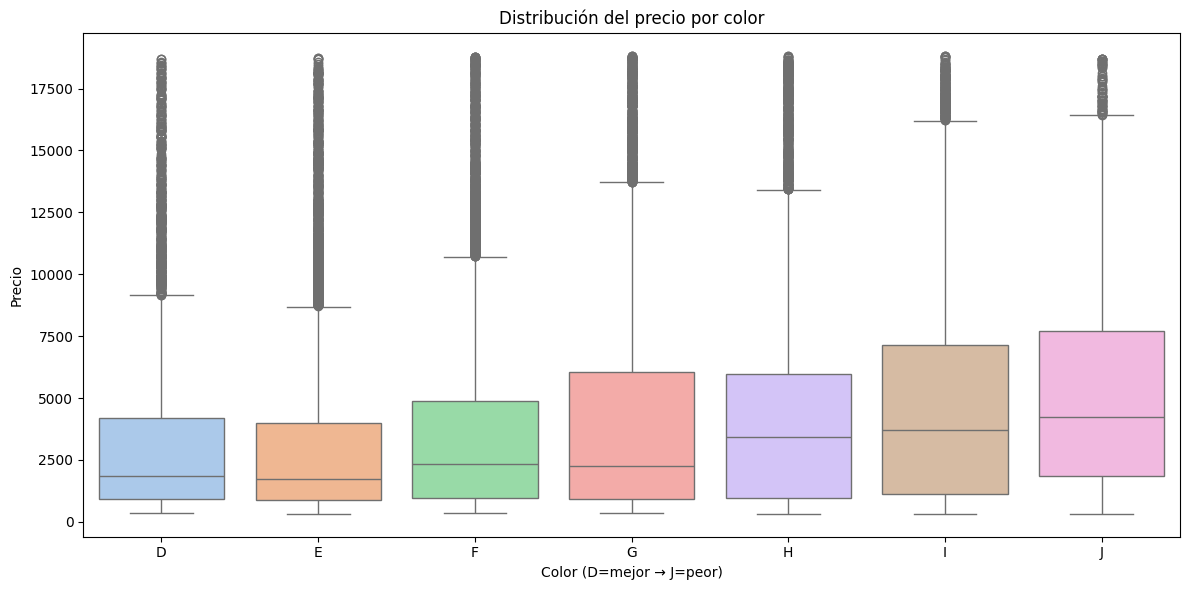

In [ ]:
orden_color = ['D', 'E', 'F', 'G', 'H', 'I', 'J']

plt.figure(figsize=(12, 6))
sns.boxplot(data=diamonds_df, x='color', y='price', order=orden_color, palette= 'pastel')
plt.title('Distribución del precio por color')
plt.xlabel('Color (D=mejor → J=peor)')
plt.ylabel('Precio')
plt.tight_layout()
plt.show()

Si comparamos el color con los quilatos el gráfico revela que los diamantes de peor color tienden a ser físicamente más grandes

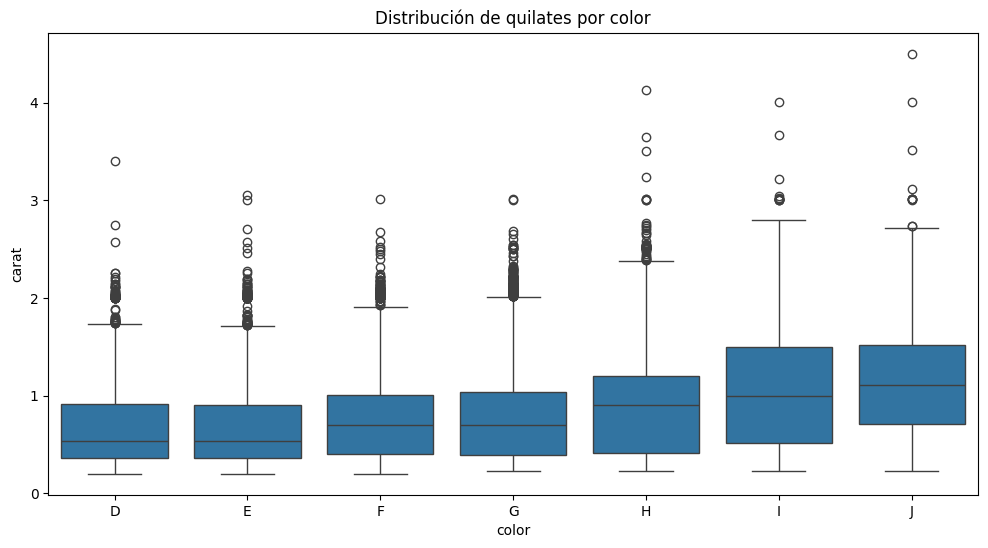

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=diamonds_df, x='color', y='carat', order=orden_color)
plt.title('Distribución de quilates por color')
plt.show()

Se confirma una tendencia positiva clara entre el peso en quilates y el precio: conforme aumenta el quilate, el precio se incrementa,  con mayor dispersión en diamantes de mayor peso. La mayoría de los datos se concentra entre 0 y 2 quilates.

Respecto a la calidad del corte, no se observa una separación clara entre categorías. Concluyendo que el quilate domina el precio por encima de la calidad del corte.

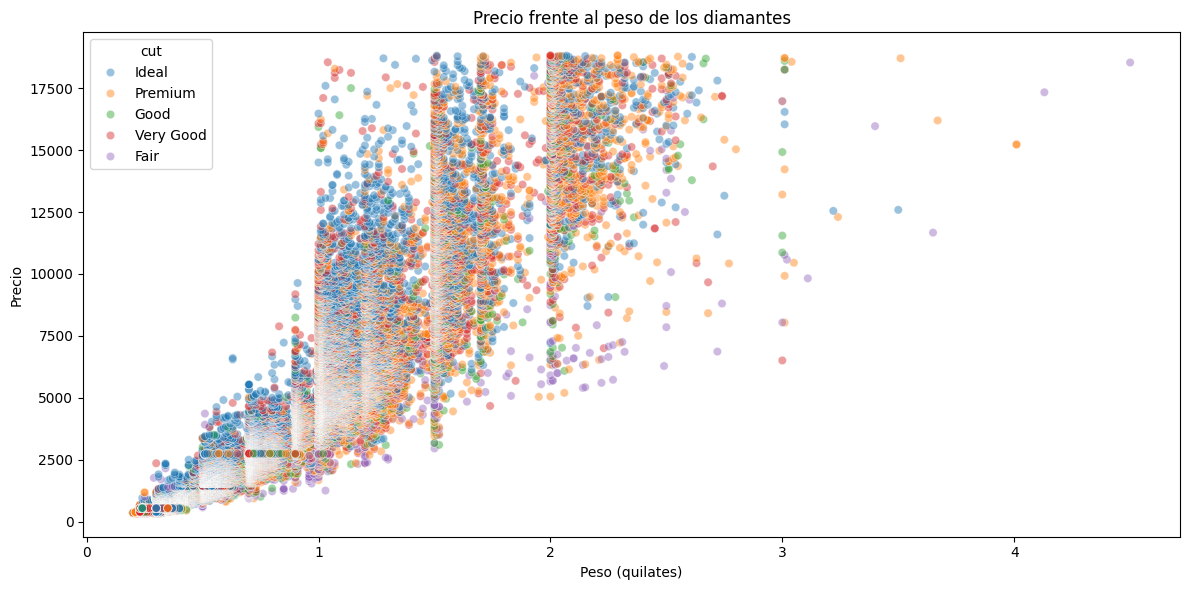

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=diamonds_df,x='carat', y='price',hue='cut', alpha = 0.45)
plt.title('Precio frente al peso de los diamantes')
plt.xlabel('Peso (quilates)')
plt.ylabel('Precio')
plt.tight_layout()
plt.show()

4. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Analiza la correlación entre los predictores (excluyendo `price`), identifica si un único predictor captura información que también está presente en varios otros y elimina los predictores redundantes para simplificar la complejidad de los modelos que construirás más adelante.
* Vuelve a generar el mapa de calor para verificar que ya no queden predictores altamente correlacionados.



---
Carat, x, y, z tienen una correlacion mayor a 0.91, lo que quiere decir que miden básicamente lo mismo, el tamano fisico del diamante, entonces un diamante más grande pesa más y mide más en todas las dimensiones.


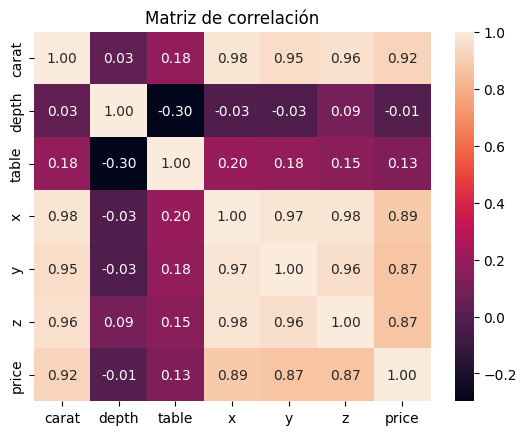

In [ ]:
sns.heatmap(diamonds_df.corr(numeric_only=True), annot=True, fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

In [ ]:
# Obtener matriz de correlación
corr_matrix = diamonds_df.corr(numeric_only=True)

# Extraer pares con correlación > 0.9 (sin duplicados ni diagonal)
pares_alta_correlacion = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):  # i+1 evita diagonal y duplicados
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            pares_alta_correlacion.append({
                'Variable 1': corr_matrix.columns[i],
                'Variable 2': corr_matrix.columns[j],
                'Correlación': round(corr_matrix.iloc[i, j], 4)
            })
pares_df = pd.DataFrame(pares_alta_correlacion).sort_values('Correlación', ascending=False)
pares_df

,Variable 1,Variable 2,Correlación
0,carat,x,0.9781
5,x,z,0.9754
4,x,y,0.9748
2,carat,z,0.9612
6,y,z,0.9566
1,carat,y,0.9542
3,carat,price,0.9218


Se identificó que las variables x, y, z  presentan correlaciones superiores a 0.95 con carat. Debido a que carat captura la misma infromacion de tamaño de forma más directa y en una sola variable, por lo que se eliminaran

In [ ]:
diamonds_df.drop(columns=['x', 'y', 'z'], inplace=True)

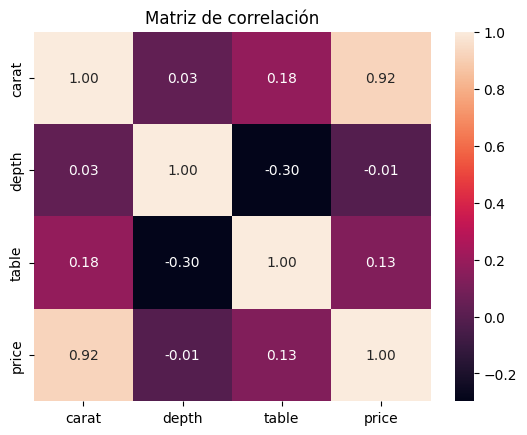

In [ ]:
sns.heatmap(diamonds_df.corr(numeric_only=True), annot=True, fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

5. Construye un modelo de regresión simple utilizando únicamente la variable predictora que tenga la mayor correlación con `price`. Para ello:
* Asigna esta variable a `X` y `price` a `y` y divide el conjunto de datos en entrenamiento y prueba (80:20), usando `random_state=1` para garantizar reproducibilidad.
* Entrena un modelo con `LinearRegression()` de scikit-learn y evalúalo en el conjunto de prueba utilizando las métricas `RMSE` (Root Mean Squared Error) y `R²` (coeficiente de determinación).
* Añade los valores obtenidos a un dataframe de resultados, que incluya el nombre del modelo (*Baseline*) y una columna para cada métrica.
* Muestra la ecuación de la regresión lineal utilizando el intercepto y el coeficiente asociado al predictor. La ecuación debe tener la forma:
> `price = intercepto + coeficiente × predictor`

In [ ]:
x = diamonds_df[['carat']]
y = diamonds_df['price']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)
lin_rmse = root_mean_squared_error(y_test, y_pred)
lin_r2 = r2_score(y_test, y_pred)

In [ ]:
resultados = pd.DataFrame(columns=['Modelo', 'RMSE', 'R2'])
resultados.loc[0] = ['Baseline', lin_rmse, lin_r2]
resultados

,Modelo,RMSE,R2
0,Baseline,1532.43849,0.84618


In [ ]:
intercepto = lin_reg.intercept_
coeficiente = lin_reg.coef_[0]
print(f"La ecuación del modelo es: price = {intercepto:.2f} + {coeficiente:.2f} * carat")

La ecuación del modelo es: price = -2276.79 + 7792.73 * carat


6. Utiliza todas las variables como predictoras para crear un segundo modelo:
* Haz la asignación correspondiente en `X` y `y` y divide en entrenamiento y prueba usando la misma configuración del ejercicio anterior.
* Prepara un transformador, denominado `preprocessing`, para aplicar escalamiento robusto a los predictores numéricos y codificación ordinal a los categóricos. Asegúrate de respetar el orden correcto de cada categoría, tal como se indica en la descripción de las variables.
* Construye un pipeline que combine el transformador creado con un modelo de regresión lineal.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Ordinal_Robust*.

In [ ]:
x = diamonds_df.drop(columns=['price'])
y = diamonds_df['price']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [ ]:
order_cut = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
order_color = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
order_clarity = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

num_cols = x.select_dtypes(include='number').columns.tolist()
cat_cols = x.select_dtypes(include='object').columns.tolist()

preprocessing = ColumnTransformer([
        ('num', RobustScaler(), num_cols),
        ('cat', OrdinalEncoder(categories=[order_cut, order_color, order_clarity]), cat_cols)])

In [ ]:
lr_model = make_pipeline(preprocessing, LinearRegression())
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
print('The Root Mean Square Error (RMSE) is:', root_mean_squared_error(y_test, y_pred))
print('The R square (R2) is:', r2_score(y_test, y_pred))

The Root Mean Square Error (RMSE) is: 1216.82221884264
The R square (R2) is: 0.9030159632731031


In [ ]:
resultados.loc[1] = ['Ordinal_Robust', root_mean_squared_error(y_test, y_pred), r2_score(y_test, y_pred)]
resultados

,Modelo,RMSE,R2
0,Baseline,1532.438490,0.846180
1,Ordinal_Robust,1216.822219,0.903016


7. Prepara otro transformador, llamado `preprocessing2`, que aplique escalamiento Min-Max a los predictores numéricos y codificación one-hot a los categóricos, asegurando `drop='first'` para prevenir multicolinealidad en las variables dummies generadas.
* Construye otro pipeline utilizando este nuevo transformador y, a continuación, entrena y evalúa el modelo.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *OHE_MinMax*.

In [ ]:
preprocessing2 = ColumnTransformer([
        ('num', MinMaxScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)])

In [ ]:
lr_model2 = make_pipeline(preprocessing2, LinearRegression())
lr_model2.fit(X_train, y_train)
y_pred = lr_model2.predict(X_test)
print('The Root Mean Square Error (RMSE) is:', root_mean_squared_error(y_test, y_pred))
print('The R square (R2) is:', r2_score(y_test, y_pred))

The Root Mean Square Error (RMSE) is: 1142.5191309289387
The R square (R2) is: 0.9144986531626278


In [ ]:
resultados.loc[2] = ['OHE_MinMax', root_mean_squared_error(y_test, y_pred), r2_score(y_test, y_pred)]
resultados

,Modelo,RMSE,R2
0,Baseline,1532.438490,0.846180
1,Ordinal_Robust,1216.822219,0.903016
2,OHE_MinMax,1142.519131,0.914499


8. Modifica el pipeline anterior para emplear regresión polinomial de segundo grado y evalúa si esto mejora el ajuste del modelo.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *PolynomialDegree2*.

In [ ]:
poly_model = make_pipeline(preprocessing2, PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
poly_model.fit(X_train, y_train)
y_pred = poly_model.predict(X_test)
print('The Root Mean Square Error (RMSE) is:', root_mean_squared_error(y_test, y_pred))
print('The R square (R2) is:', r2_score(y_test, y_pred))

The Root Mean Square Error (RMSE) is: 749.0262783054925
The R square (R2) is: 0.9632514588490314


In [ ]:
resultados.loc[3] = ['PolynomialDegree2', root_mean_squared_error(y_test, y_pred), r2_score(y_test, y_pred)]
resultados

,Modelo,RMSE,R2
0,Baseline,1532.438490,0.846180
1,Ordinal_Robust,1216.822219,0.903016
2,OHE_MinMax,1142.519131,0.914499
3,PolynomialDegree2,749.026278,0.963251


9. Ordena el dataframe de resultados según el `R²`, de manera que el modelo con mejor desempeño aparezca primero.
* Para dicho modelo, crea un gráfico de dispersión de los valores reales frente a los predichos, e incluye una línea diagonal de referencia para indicar una predicción perfecta.

In [ ]:
resultados.sort_values('R2', ascending=False, inplace=True)
resultados

,Modelo,RMSE,R2
3,PolynomialDegree2,749.026278,0.963251
2,OHE_MinMax,1142.519131,0.914499
1,Ordinal_Robust,1216.822219,0.903016
0,Baseline,1532.438490,0.846180


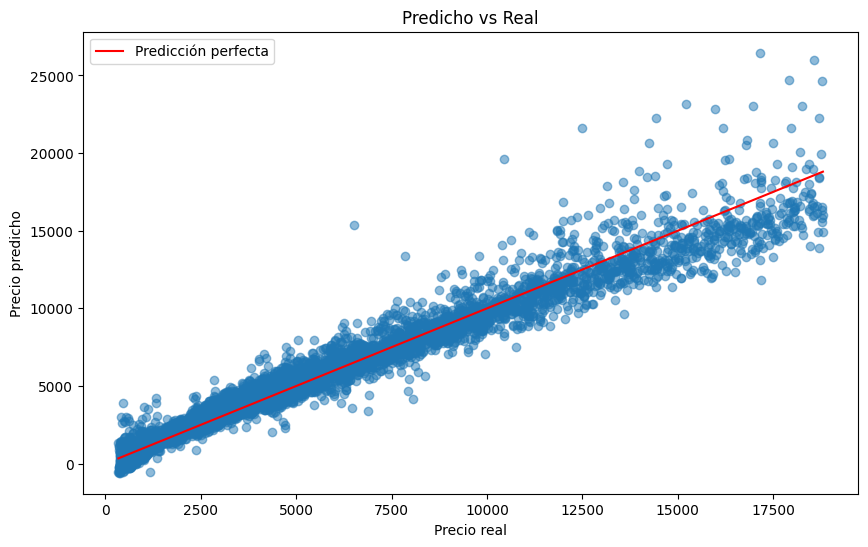

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)


lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, c='red', label='Predicción perfecta')

plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Predicho vs Real')
plt.legend()
plt.show()

10. Muestra la representación gráfica del pipeline para ubicar la posición de cada elemento dentro del flujo del modelo.
* Obtén los nombres de todas las columnas después del preprocesamiento (numéricas y dummies de categóricas).
* Extrae los nombres de las columnas polinómicas.
* Recupera los coeficientes y el intercepto del modelo de regresión lineal.
* Ordena los coeficientes por su valor absoluto para mostrar los 10 más importantes y da conclusiones sobre cómo los distintos factores influyen en el precio.

In [ ]:
poly_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['carat', 'depth', 'table']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['cut', 'color',
                                                   'clarity'])])),
                ('polynomialfeatures', PolynomialFeatures(include_bias=False)),
                ('linearregression', LinearRegression())])

In [ ]:
columnames = poly_model.named_steps['columntransformer'].get_feature_names_out()
poly_names = poly_model.named_steps['polynomialfeatures'].get_feature_names_out(columnames)
coefs = poly_model.named_steps['linearregression'].coef_
intercepto = poly_model.named_steps['linearregression'].intercept_

 9 de los 10 términos involucran carat, confirmando que el tamaño del diamante es, por mucho, el factor dominante en la determinación del precio.

 Estos resultados muestran que carat, clarity y color no actúan de forma independiente sobre el precio, sino que interactúan

In [ ]:
coef_df = pd.DataFrame({'Nombre': poly_names, 'Coeficientes': coefs})
coef_df['Coef_abs'] = coef_df['Coeficientes'].abs()
coef_df.sort_values('Coef_abs', ascending=False, inplace=True)
coef_df.head(10)

,Nombre,Coeficientes,Coef_abs
20,num__carat^2,55138.858509,55138.858509
33,num__carat cat__clarity_IF,49901.936113,49901.936113
38,num__carat cat__clarity_VVS1,46676.323033,46676.323033
39,num__carat cat__clarity_VVS2,44778.304459,44778.304459
36,num__carat cat__clarity_VS1,40030.092696,40030.092696
37,num__carat cat__clarity_VS2,37092.587930,37092.587930
34,num__carat cat__clarity_SI1,31996.751829,31996.751829
35,num__carat cat__clarity_SI2,24370.331563,24370.331563
32,num__carat cat__color_J,-20648.289435,20648.289435
31,num__carat cat__color_I,-14267.848139,14267.848139


---

**Declaración de uso de IA**

*  Anthropic. (2026) Claude (claude-sonnet-4-6) [Modelo de lenguaje grande], utilizado para generación de código y depuración. https://claude.ai

---